## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load session

In [3]:
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)

### Styling

In [4]:
from matplotlib.colors import ListedColormap

# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '110' if '110' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : '',
    '70' : '-30% CH4',
    '100' : '+/-0% CH4',
    '110' : '+10% CH4'
}

rename_scn = lambda x: x.lower().replace('_','-') if x != 'BL' else 'Baseline'

# Sensitivity analysis Scenarios 
sens = []

# Scenario sort
sort = list(
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .xs('100', level='year')
    .sum(axis=1)
    .sort_values()
    .index
)
# Add BL and remove sensitivity analysis scenarios
sort = ['BL'] + [s for s in sort if s not in sens]

def _legend_r(ax):  
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
def _legend_t(ax):  
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.3), frameon=False, ncol=2, fontsize=9, reverse=True)

def _LSU(x):
    '''Gives livestock units (LSU) per head based on a tuple of (species, breed, animal)
    according to https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Glossary:Livestock_unit_(LSU)'''
    sp,br,an = x
    if sp == 'cattle':
        if an == 'cows':
            if br == 'dairy':
                return 1
            else:
                return 0.8
        elif an == 'calves':
            return 0.4
        elif an == 'breeding bulls':
            return 1
        else:
            return 0.8
    elif sp == 'sheep':
        return 0.1
    elif sp == 'pigs':
        if an == 'piglets':
            return 0.027
        elif an == 'sows':
            return 0.5
        else:
            return 0.3
    elif sp == 'horses':
        return 0.8
    elif sp == 'poultry':
        if an == 'broilers':
            return 0.007
        else:
            return 0.014
    else:
        return np.nan

## Plot results

### Bars: Main results

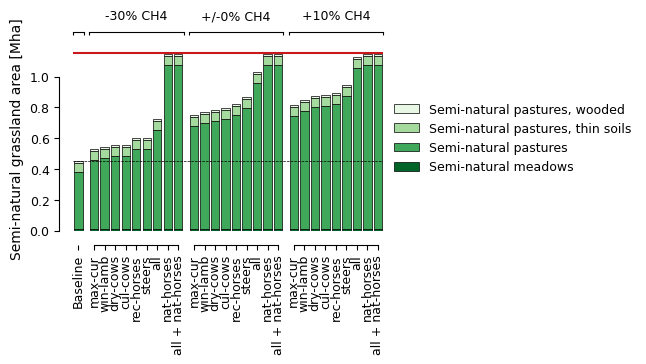

In [5]:
# SNG AREA ---------------------------------------------------------------------- ##
fig, ax = plt.subplots(figsize=(4,2.4))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
)/1_000_000

max_sng = session.get_attr('r','max_land_use','land_use').loc[('MAX_CUR','100'),'semi-natural grasslands'] / 1_000_000

cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap='Greens',
    ylabel='Semi-natural grassland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9,
    ylim = (0,1.2)
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
ax.axhline(max_sng, c='#cb181d', linewidth=1.5, linestyle='-')
_legend_r(ax)

plt.show()

species,"cattle, beef","cattle, dairy","horses, cons.","horses, recr.",pigs,poultry,sheep
scn,,,,,,,
MAX_CUR,1,1,0,-0,0,0,0
WIN_LAMB,-5,-8,0,-0,0,0,9
DRY_COWS,-16,21,0,-0,0,0,-0
CUL_COWS,-15,11,0,-0,0,0,-0
REC_HORSES,1,1,0,0,0,0,0
STEERS,-7,-13,0,-0,0,0,-3
ALL,-37,13,0,0,0,0,4
NAT_HORSES,-33,-51,321,-0,0,0,-3
ALL + NAT_HORSES,-55,-19,187,-0,0,0,2


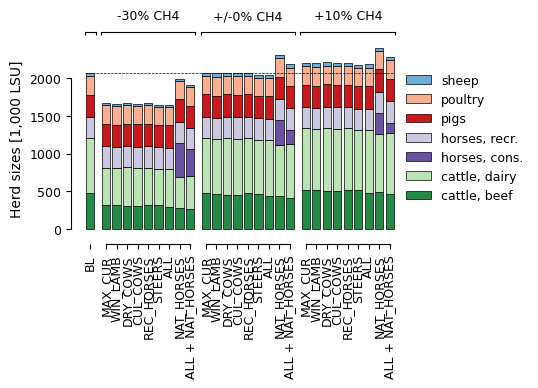

In [6]:
plot_data = (
    session.get_attr('a','heads',['species','breed','animal'])
    .rename(rename_years)
) / 1_000
# Convert to LSU
plot_data = plot_data.mul([_LSU(x) for x in plot_data.columns], axis=1)

plot_data.columns = pd.Index(
    [f'{sp}, {br}' if sp == 'cattle'
     else 'horses, recr.' if sp == 'horses' and 'cons' not in br
     else 'horses, cons.' if sp == 'horses'
     else sp
     for sp,br,an in plot_data.columns],
    name = 'species'
)

plot_data = plot_data.T.groupby('species').sum().T

display(plot_data.loc[sort].sub(plot_data.loc[('BL','')], axis=1).xs('+/-0% CH4', level='year').style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(4,2.4))
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#6a51a3', '#cbc9e2', '#cb181d', '#fcae91', '#6baed6']),
    ylabel='Herd sizes [1,000 LSU]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

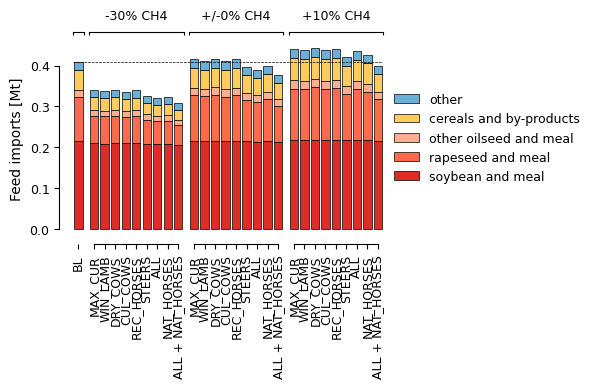

In [7]:
by_prod_agg = {
    'fish meal' : 'other',
    'luzern meal' : 'other',
    'milling by-products from wheat, barley or rye' : 'cereals and by-products',
    'palm kernel expeller' : 'other oilseed and meal',
    'potatoe protein' : 'other',
    'rapeseed cake' : 'rapeseed and meal',
    'rapeseed meal' : 'rapeseed and meal',
    'soybean meal' : 'soybean and meal',
    'soybean protein concentrate' : 'soybean and meal',
    'sugar beet molasses' : 'other',
    'sugar beet pulp' : 'other',
    'sunflower seed meal' : 'other oilseed and meal',
    'wheat distillers grain' : 'cereals and by-products'
}

crop_prod_agg = {
    'linseed' : 'other oilseed and meal',
    'maize' : 'cereals and by-products',
    'soybeans' : 'soybean and meal'
}

plot_data = pd.concat([
    (
        session.get_attr('a','feed.crop_prod',['origin','crop_prod'])
        .loc[:,'imported']
        .rename(columns = crop_prod_agg)
        .rename_axis(columns = 'item')
        .rename(rename_years)
    ),
    (
        session.get_attr('d','by_products',['origin','by_prod'])
        .loc[:,'imported']
        .rename(columns = by_prod_agg)
        .rename_axis(columns = 'item')
        .rename(rename_years)
    )
], axis=1).T.groupby('item').sum().T / 1_000_000_000

item_sort = ['soybean and meal', 'rapeseed and meal', 'other oilseed and meal', 'cereals and by-products', 'other']

fig, ax = plt.subplots(figsize=(4,2.4))
cm.plot.bar(
    plot_data.loc[sort,item_sort],
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fb6a4a', '#fcae91', '#fecc5c', '#6baed6']),
    ylabel='Feed imports [Mt]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

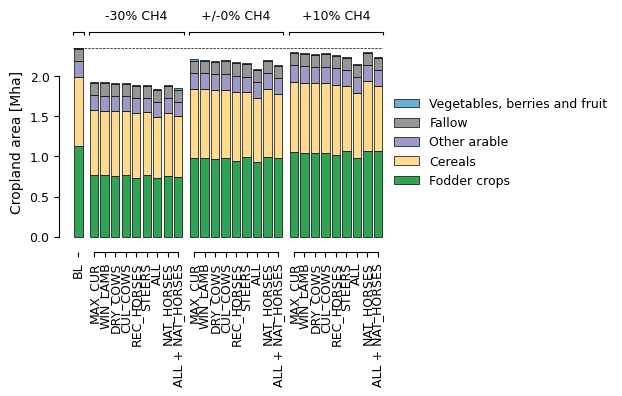

In [8]:
# CROP AREA ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[:,'cropland']
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#31a354','#fed98e', '#9e9ac8', '#969696', '#6baed6']),
    ylabel='Cropland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

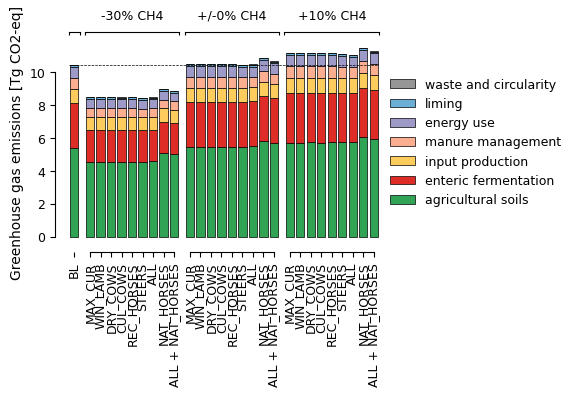

In [9]:
# GHG ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
    .rename(rename_years)
)/1000000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#31a354','#de2d26', '#fecc5c', '#fcae91', '#9e9ac8', '#6baed6', '#969696']),
    ylabel='Greenhouse gas emissions [Tg CO2-eq]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

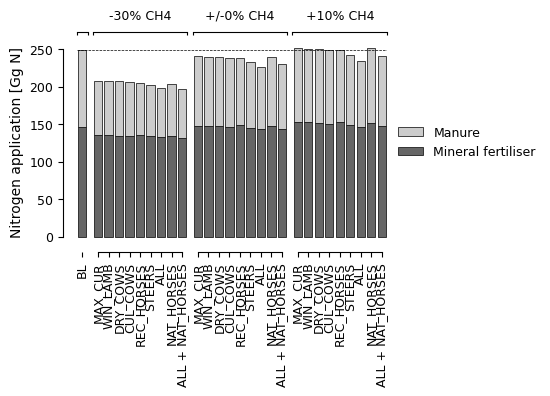

In [10]:
# N FERTILISER ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    pd.concat([
        session.get_attr('c','fertiliser.mineral_N', {'crop':'land_use'}).loc[:,'cropland'].rename('Mineral fertiliser'),
        session.get_attr('c','fertiliser.manure_N', {'crop':'land_use'}).loc[:,'cropland'].rename('Manure')
    ], axis=1)
    .rename(rename_years)
)/1000000

cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#666666','#cccccc']),
    ylabel='Nitrogen application [Gg N]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

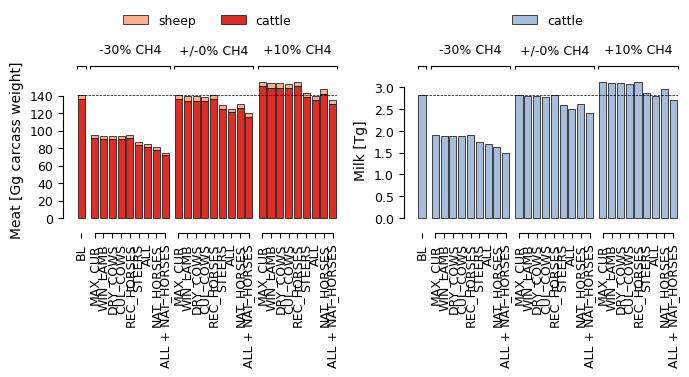

In [11]:
# MEAT AND MILK ---------------------------------------------------------------------- ##
fig, axs = plt.subplots(1,2, figsize=(7,4.5))
plot_data = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
)/1000000
ax = axs[0]
cm.plot.bar(
    plot_data.loc[:,'meat'].loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fcae91']),
    ylabel='Meat [Gg carcass weight]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL',''),'meat'].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)
ax = axs[1]
cm.plot.bar(
    plot_data.loc[:,'milk'].loc[sort]/1000,
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#a6bddb']),
    ylabel='Milk [Tg]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL',''),'milk'].sum()/1000, c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)

plt.tight_layout()
plt.show()

### Bars: Grazing

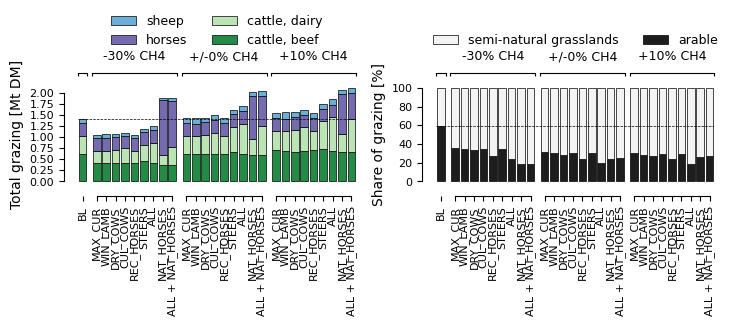

In [12]:
d1 = (
    session
    .get_attr('a','feed.crop_product_demand',['crop_prod','species','breed'])
    .loc[:,'grazing']
    .rename(rename_years)
    .loc[sort]
    /1_000_000_000
)
d1.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in d1.columns], name='animal_system')
d1 = d1.T.groupby('animal_system').sum().T

d2 = (
    session
    .get_attr('c','production',{'crop_prod':None, 'crop':'land_use'})
    .loc[:,'grazing']
    .apply(lambda x: x/x.sum()*100, axis=1)
    .rename(rename_years)
    .rename(columns={'cropland':'arable'})
    .loc[sort]
)

fig,axs = plt.subplots(1,2, figsize=(7.5,4))
ax = axs[0]
cm.plot.bar(
    d1,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#756bb1', '#6baed6']),
    ylabel='Total grazing [Mt DM]',
    ylabel_fontsize=10,
    ticklabels_fontsize=8,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d1.sum(axis=1).loc['BL'].iloc[0], c='black', linewidth=0.5, linestyle='--')

ax = axs[1]
cm.plot.bar(
    d2,
    group_levels='year',
    cmap='Greys',
    ylabel='Share of grazing [%]',
    ylabel_fontsize=10,
    ticklabels_fontsize=8,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d2.loc['BL','arable'].iloc[0], c='black', linewidth=0.5, linestyle='--')

for ax in axs.flatten():
    _legend_t(ax)

plt.tight_layout()
plt.show()

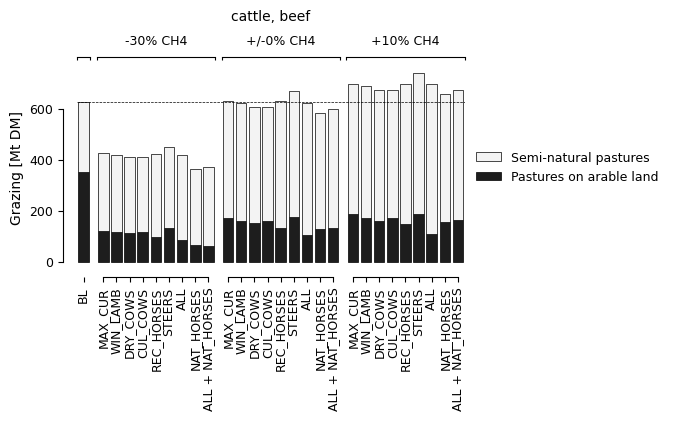

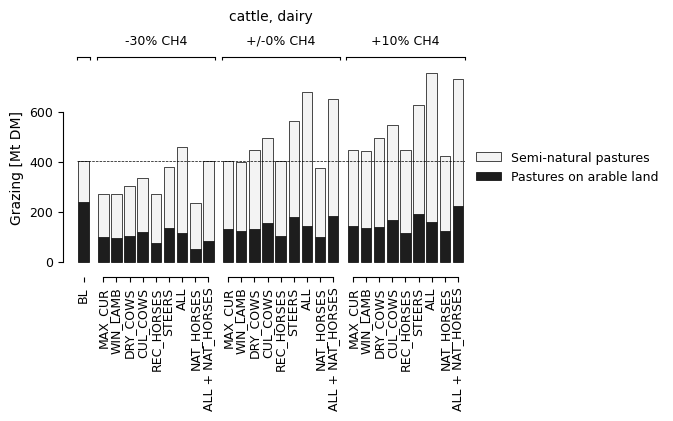

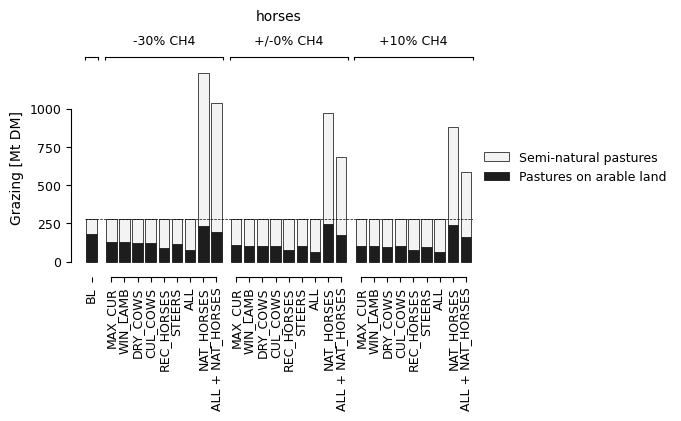

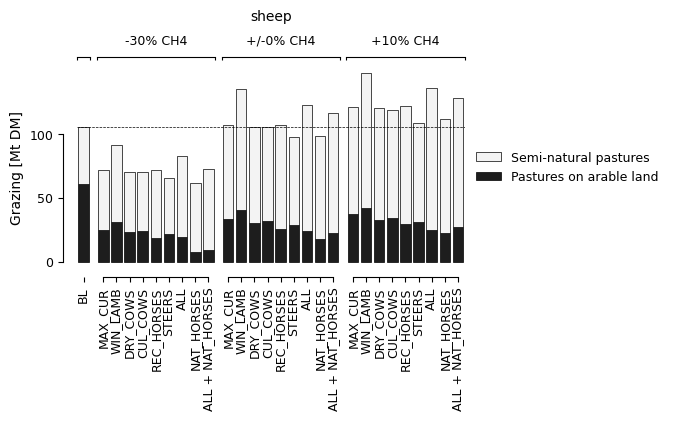

In [13]:
rename_crp = {
    'Ley for grazing' : 'Pastures on arable land',
    'Semi-natural pastures' : 'Semi-natural pastures',
    'Semi-natural pastures, thin soils' : 'Semi-natural pastures',
    'Semi-natural pastures, wooded' : 'Semi-natural pastures'
}

plot_data = (
    session.get_attr('c','production_per_use', ['crop', 'demand'])
    .rename(rename_years)
    .loc[sort,list(rename_crp)]
    .rename(columns=rename_crp, level='crop')
    .rename(
        columns=lambda x:
            'cattle, dairy' if 'cattle, dairy' in x else
            'cattle, beef' if 'cattle, beef' in x else
            'sheep' if 'sheep' in x else
            'horses' if 'horses' in x else
            '',
        level='demand'
    )
    .T.groupby(['crop','demand']).sum().T
    .rename_axis(columns={'demand':'animal_system'})
    .stack('animal_system')
)/1_000_000

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='Greys'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

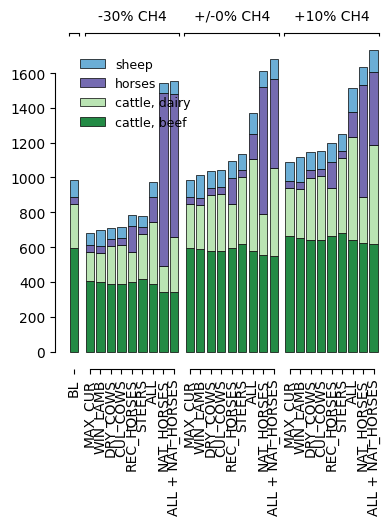

In [14]:
plot_data = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group','species','breed'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
)/1_000_000
plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
plot_data = plot_data.T.groupby('animal_system').sum().T

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#756bb1', '#6baed6']),
    ax=ax
)
plt.show()

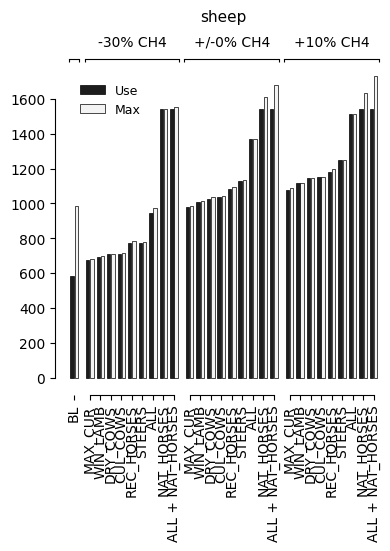

In [15]:
use_df = (
    session.get_attr('c','production', {'crop':'crop_group'})
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Use')
)/1_000_000

max_df = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Max')
)/1_000_000

plot_data = pd.concat([use_df,max_df], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='year',
    cmap='Greys',
    grouptitle=ani,
    ax=ax
)
plt.show()

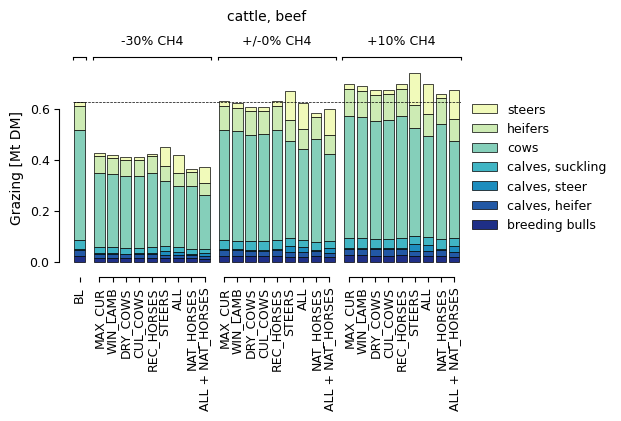

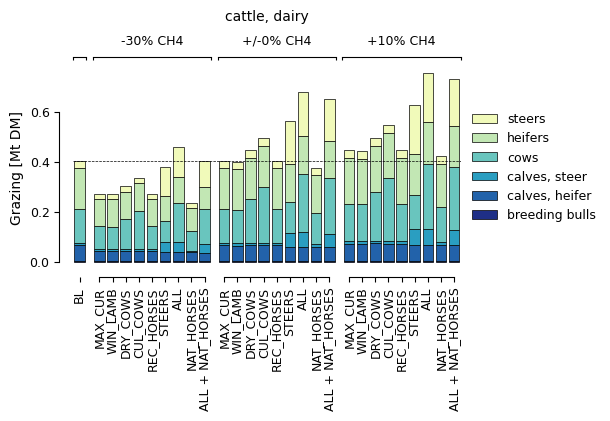

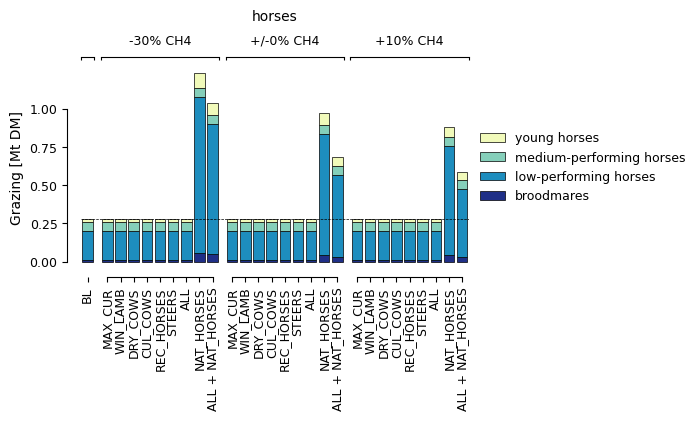

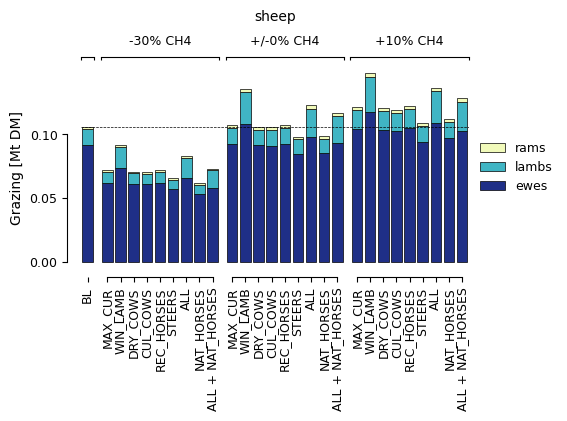

In [16]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .rename(rename_years)
    .loc[sort,('domestic','grazing')]
    .stack(['species','breed'])
)/1_000_000_000
plot_data.index = pd.MultiIndex.from_tuples(
    [( scn, y, sp if sp != 'cattle' else ', '.join([sp,br]) ) for scn,y,sp,br in plot_data.index],
    names = ['scn', 'year', 'animal_system']
)
plot_data = plot_data.groupby(['scn', 'year', 'animal_system'], sort=False).sum()

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='YlGnBu'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

### Maps: Potential pastures and yield

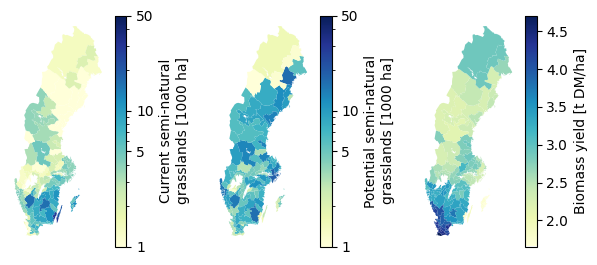

In [17]:
import matplotlib

a0 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('BL','0'), 'semi-natural grasslands']/1000
a1 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('MAX_CUR','100'), 'semi-natural grasslands']/1000
y = (
    (session.get_attr('c','harvest',{'crop':'land_use','region':None})
    /session.get_attr('c','area',{'crop':'land_use','region':None}))
    .loc[('BL','0'),'semi-natural grasslands']
)/1000

fig, axs = plt.subplots(1,3, figsize=(7.5,3))
ax = axs[0]
cm.plot.map_from_series(a0, cmap='YlGnBu', norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Current semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax = axs[1]
cm.plot.map_from_series(a1-a0, cmap='YlGnBu', norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Potential semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax=axs[2]
cm.plot.map_from_series(y, cmap='YlGnBu', ax=ax, legend=False)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biomass yield [t DM/ha]', fontsize=10)
ax.axis('off')

plt.tight_layout
plt.show()

### Maps: Changes in semi-natural grassland and cropland area

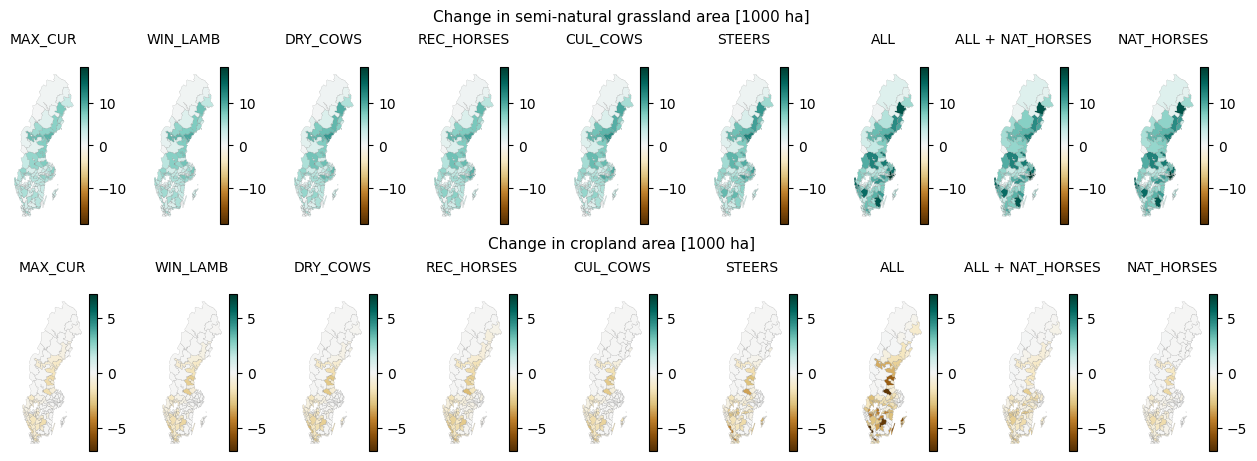

In [18]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1000

scn_sorted = plot_data.sum(axis=1).sort_values().index

n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

fig = plt.figure(layout='constrained', figsize=(1.4*n_scn, 4.5))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)

# fig.tight_layout()
plt.show()

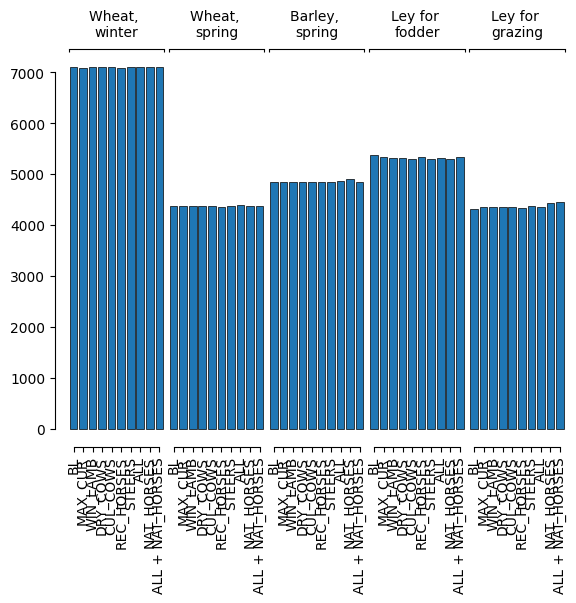

In [19]:
d=(
    (
    session.get_attr('c','harvest',{'crop':None}) /
    session.get_attr('c','area',{'crop':None})
    )
    .loc[scn_final,['Wheat, winter','Wheat, spring', 'Barley, spring', 'Ley for fodder', 'Ley for grazing']]
    .loc[sort]
    .stack()
    .droplevel('year')
)

cm.plot.bar(d, group_levels='crop')
plt.show()

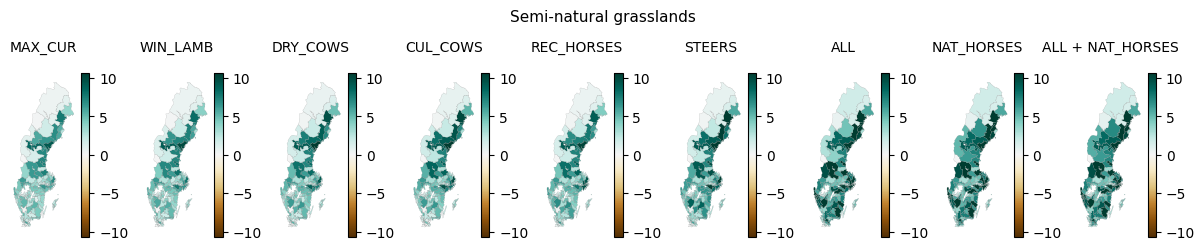

,0,1
scn,,
MAX_CUR,363.3,491.4
WIN_LAMB,395.1,530.9
DRY_COWS,420.3,558.7
CUL_COWS,429.3,565.6
REC_HORSES,439.2,596.0
STEERS,494.5,663.6
ALL,674.7,927.8
NAT_HORSES,691.6,954.9
ALL + NAT_HORSES,692.4,955.8


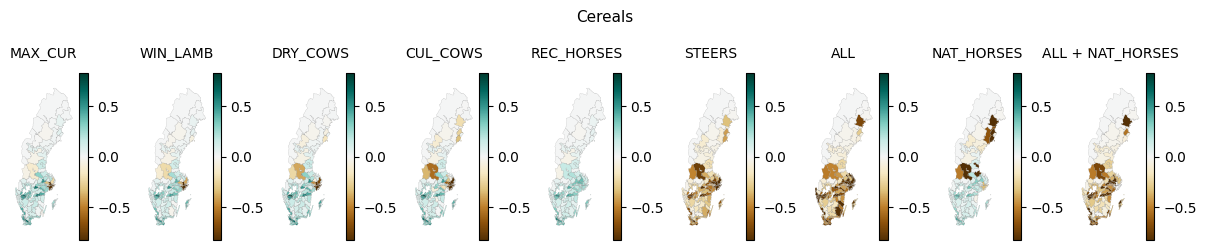

,0,1
scn,,
MAX_CUR,16.7,88.1
WIN_LAMB,13.5,73.5
DRY_COWS,15.4,86.2
CUL_COWS,10.7,64.6
REC_HORSES,17.0,88.0
STEERS,-37.8,-191.0
ALL,-49.8,-246.4
NAT_HORSES,2.6,34.5
ALL + NAT_HORSES,-42.8,-221.2


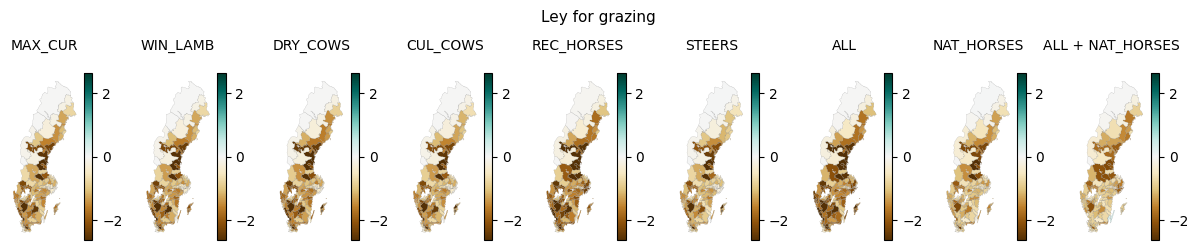

,0,1
scn,,
MAX_CUR,-136.1,-362.7
WIN_LAMB,-145.3,-387.8
DRY_COWS,-152.8,-408.0
CUL_COWS,-135.7,-360.4
REC_HORSES,-173.5,-466.5
STEERS,-123.8,-326.6
ALL,-178.4,-478.0
NAT_HORSES,-115.5,-297.0
ALL + NAT_HORSES,-103.5,-260.0


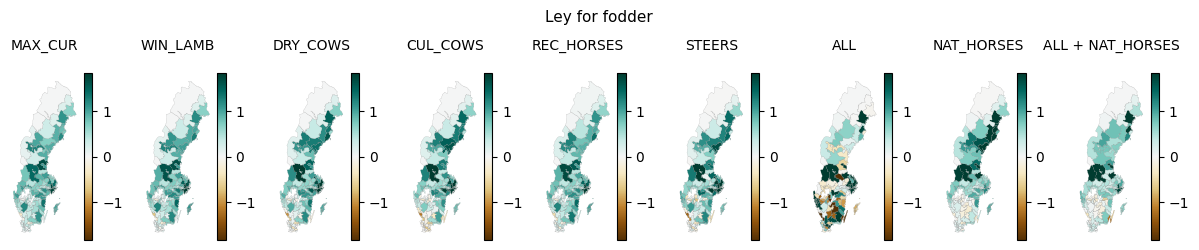

,0,1
scn,,
MAX_CUR,61.3,300.3
WIN_LAMB,62.8,301.5
DRY_COWS,58.6,267.7
CUL_COWS,51.4,221.2
REC_HORSES,61.8,299.2
STEERS,56.3,252.5
ALL,27.1,107.4
NAT_HORSES,59.4,268.6
ALL + NAT_HORSES,42.9,198.1


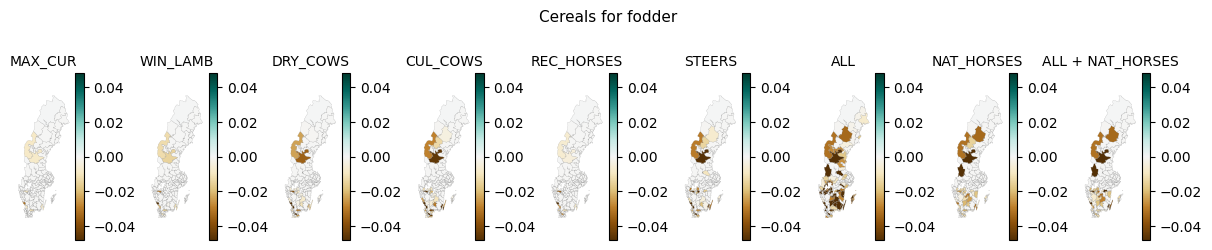

,0,1
scn,,
MAX_CUR,-0.1,-0.4
WIN_LAMB,-0.2,-0.8
DRY_COWS,-0.5,-2.0
CUL_COWS,-0.8,-3.3
REC_HORSES,-0.2,-0.8
STEERS,-0.9,-3.4
ALL,-4.4,-15.5
NAT_HORSES,-0.7,-2.3
ALL + NAT_HORSES,-1.0,-3.4


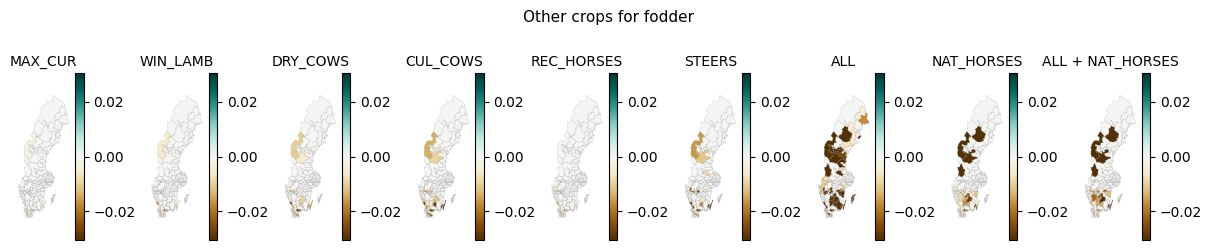

,0,1
scn,,
MAX_CUR,-0.0,-0.2
WIN_LAMB,-0.1,-0.4
DRY_COWS,-0.2,-1.1
CUL_COWS,-0.4,-1.9
REC_HORSES,-0.1,-0.3
STEERS,-0.4,-1.9
ALL,-2.9,-12.8
NAT_HORSES,-0.6,-2.1
ALL + NAT_HORSES,-0.8,-3.1


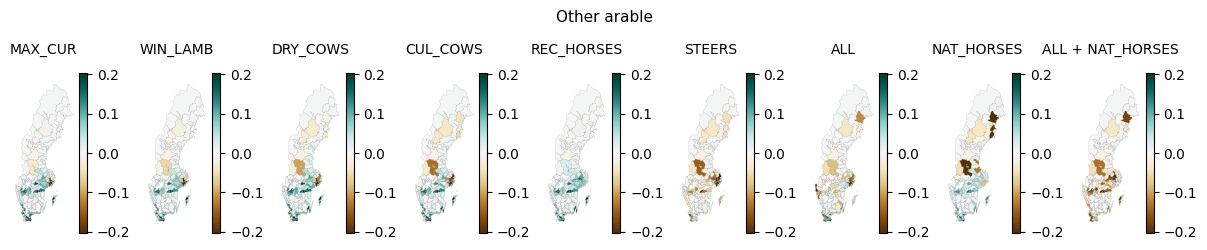

,0,1
scn,,
MAX_CUR,4.8,15.8
WIN_LAMB,4.0,13.7
DRY_COWS,5.1,17.4
CUL_COWS,3.9,14.2
REC_HORSES,5.0,15.9
STEERS,-3.7,-11.0
ALL,-1.8,-3.4
NAT_HORSES,1.8,7.3
ALL + NAT_HORSES,-6.7,-21.5


In [20]:
d1 = (
    session.get_attr('c','area',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d2 = (
    session.get_attr('c','area',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d3 = (
    session.get_attr('c','production',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

d4 = (
    session.get_attr('c','production',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

s = d1.loc[:,'Semi-natural grasslands'].sum(axis=1).sort_values().index
d1 = d1.loc[s]
d2 = d2.loc[s]
d3 = d3.loc[s]
d4 = d4.loc[s]

n_scn = len(d1)

crps = ['Semi-natural grasslands','Cereals','Ley for grazing','Ley for fodder','Cereals for fodder','Other crops for fodder','Other arable']

for crp in crps:
    try:
        d = d1.loc[:,crp]
        p = d3.loc[:,crp]
    except KeyError:
        d = d2.loc[:,crp]
        p = d4.loc[:,crp]
    lim = np.quantile(d.abs(),0.95)
    
    fig, axs = plt.subplots(1,n_scn, figsize=(1.35*n_scn,2.5))
    for i, scn in enumerate(d.index):
        ax=axs[i]
        cm.plot.map_from_series(
            d.loc[scn],
            ax=ax,
            vmin=-lim,
            vmax=lim,
            **map_style_div
        )
        ax.set_title(scn, size=10)
        ax.axis('off')
    plt.suptitle(f'{crp}', size=11)
    plt.tight_layout()
    plt.show()
    display(pd.concat([d.sum(axis=1),p.sum(axis=1)], axis=1).style.format(precision=1))


#### Share of pot. SNG

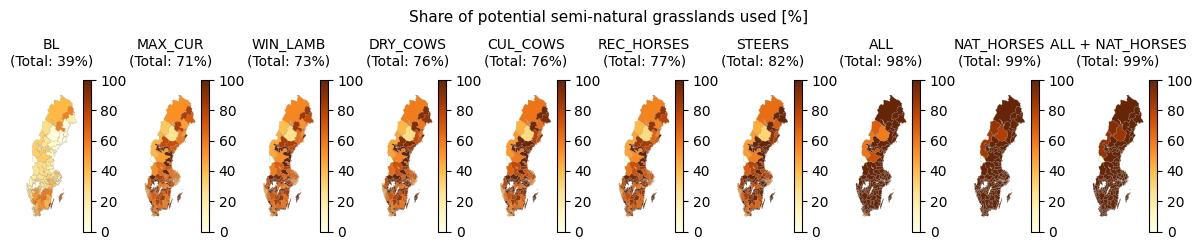

In [21]:
sng_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'semi-natural grasslands']
sng_pot = session.get_attr('r','max_land_use',['land_use','region']).loc[('MAX_CUR','100'),'semi-natural grasslands']
tot_share = (sng_use.sum(axis=1) / sng_pot.sum()).droplevel('year')*100

plot_data = (
    sng_use.div(sng_pot, axis=1)
    .droplevel('year')
) * 100

fig, axs = plt.subplots(1,len(sort), figsize=(12,2.5))
for n, scn in enumerate(sort):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of potential semi-natural grasslands used [%]', size=11)
plt.tight_layout()
plt.show()

#### Share of max cropland

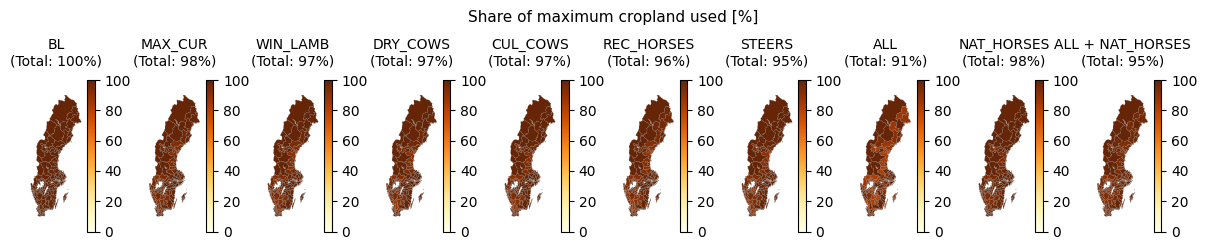

In [22]:
cropland_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'cropland']
cropland_max = session.get_attr('r','max_land_use',['land_use','region']).loc[('MAX_CUR','100'),'cropland']
tot_share = (cropland_use.sum(axis=1) / cropland_max.sum()).droplevel('year')*100

plot_data = (
    cropland_use.div(cropland_max, axis=1)
    .droplevel('year')
) * 100

fig, axs = plt.subplots(1,len(sort), figsize=(12,2.5))
for n, scn in enumerate(sort):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of maximum cropland used [%]', size=11)
plt.tight_layout()
plt.show()

### Maps. Changes in animal herds

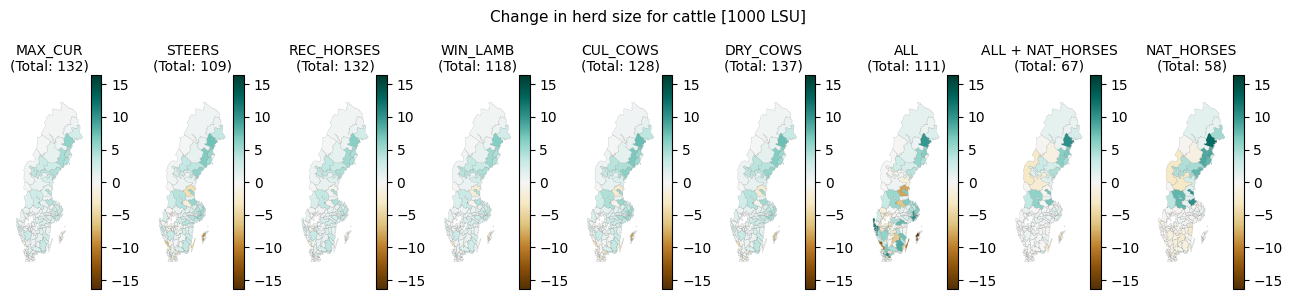

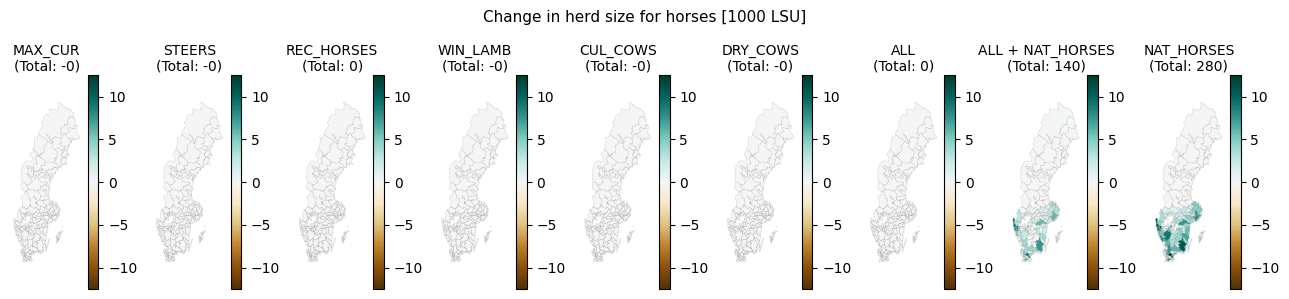

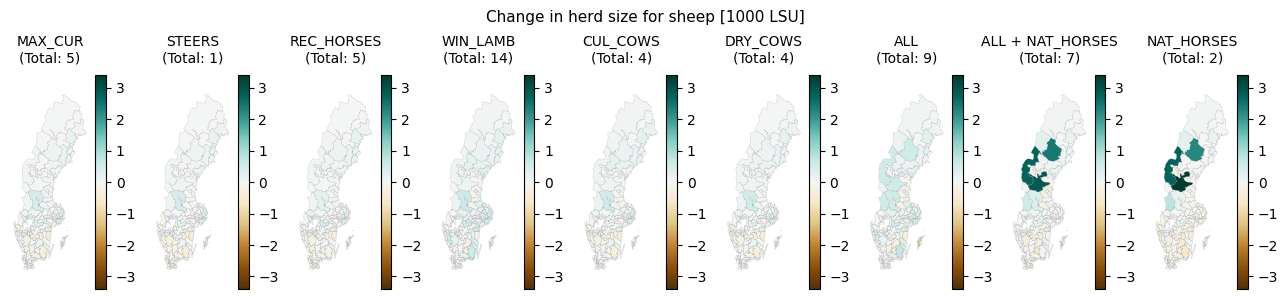

In [23]:
plot_data = (
    cm.impact.get_LSU(session, ['region','species'])
    .loc[scn_final]
    .droplevel('year')
    .transform(lambda x: x.sub(x.loc[('BL')],axis=1))
    .drop('BL')
    .stack('region')
)/1000
# plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
# plot_data = plot_data.T.groupby('animal_system').sum().T

plot_data = plot_data.drop(['pigs','poultry'], axis=1)

for ani in plot_data.columns:
    d = plot_data.loc[:,ani]

    lim = max(-min(d.values), max(d.values))
    
    fig, axs = plt.subplots(1,len(d.index.unique('scn')), figsize=(13,3))
    for n, scn in enumerate(d.index.unique('scn')):
        ax = axs[n]
        cm.plot.map_from_series(
            d.loc[scn],
            ax = ax,
            vmin = -lim,
            vmax = lim,
            **map_style_div
        )
        ax.set_title(f'{scn}\n(Total: {d.loc[scn].sum():.0f})', size=10)
        ax.axis('off')
    fig.suptitle(f'Change in herd size for {ani} [1000 LSU]', size=11)
    plt.tight_layout()
    plt.show()